In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

class LogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate  = learning_rate  
        self.epochs         = epochs        
        self.weights_       = None         
        self.bias_          = None          
        self.x_cols_        = None
        self.y_col_         = None
        self._X             = None
        self._Y             = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))


    def fit(self, df: pd.DataFrame, x_cols, y_col: str):
        
        self._X      = df[x_cols].astype(float).values  
        self._Y      = df[y_col].astype(float).values   
        self.x_cols_ = x_cols
        self.y_col_  = y_col

        n_samples, n_features = self._X.shape

        # start everything at zero 
        self.weights_ = np.zeros(n_features)
        self.bias_    = 0.0

        for epoch in range(self.epochs):

            # w1*x1 + w2*x2 + ... + bias
            z = np.dot(self._X, self.weights_) + self.bias_

            Y_pred = self._sigmoid(z)

            #error
            error = Y_pred - self._Y

            dw = np.dot(self._X.T, error) / n_samples
            db = np.sum(error) / n_samples

            self.weights_ -= self.learning_rate * dw
            self.bias_    -= self.learning_rate * db

        print(f"Model trained on {x_cols} -> '{y_col}'")
        print(f"Epochs: {self.epochs}  |  Learning rate: {self.learning_rate}")
        for col, w in zip(x_cols, self.weights_):
            print(f"  Weight [{col}]: {w:.4f}")
        print(f"  Bias: {self.bias_:.4f}")
        return self

    def predict_proba(self, X):
        X_arr  = self._coerce_input(X)
        z      = np.dot(X_arr, self.weights_) + self.bias_
        proba  = self._sigmoid(z)
        for i, p in enumerate(proba):
            print(f"[predict_proba] sample {i+1}  ->  P(class=1) = {p:.4f}")
        return proba

    def predict(self, X, threshold=0.5):
        proba       = self.predict_proba(X)
        predictions = (proba >= threshold).astype(int)
        for i, (p, cls) in enumerate(zip(proba, predictions)):
            print(f"[predict]       sample {i+1}  ->  class = {cls}  (prob={p:.4f})")
        return predictions

    def score(self):
        z      = np.dot(self._X, self.weights_) + self.bias_
        proba  = self._sigmoid(z)
        Y_pred = (proba >= 0.5).astype(int)
        Y_true = self._Y.astype(int)

        TP = np.sum((Y_pred == 1) & (Y_true == 1))
        TN = np.sum((Y_pred == 0) & (Y_true == 0))
        FP = np.sum((Y_pred == 1) & (Y_true == 0))
        FN = np.sum((Y_pred == 0) & (Y_true == 1))

        accuracy  = (TP + TN) / len(Y_true)
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        print(f"[score] Accuracy  = {accuracy:.4f}  ({'excellent' if accuracy > 0.9 else 'good' if accuracy > 0.7 else 'weak'})")
        print(f"        Precision = {precision:.4f}")
        print(f"        Recall    = {recall:.4f}")
        print(f"        F1 Score  = {f1:.4f}")
        return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

    def plot(self):
        if len(self.x_cols_) != 1:
            print("plot() only works for single-feature models.")
            return

        x_line = np.linspace(self._X.min() - 1, self._X.max() + 1, 300)
        z      = self.weights_[0] * x_line + self.bias_
        y_line = self._sigmoid(z)   # the S-curve

        plt.figure(figsize=(7, 4))

        # scatter: color by actual class
        for cls, color, label in [(0, "red", "Class 0"), (1, "steelblue", "Class 1")]:
            mask = self._Y == cls
            plt.scatter(self._X[mask], self._Y[mask],
                        color=color, marker="*", s=100, zorder=5, label=label)

        # S-curve
        plt.plot(x_line, y_line, color="green", linewidth=2, label="Sigmoid curve")

        # decision boundary at 0.5
        plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Decision boundary (0.5)")

        plt.xlabel(self.x_cols_[0])
        plt.ylabel(f"P({self.y_col_} = 1)")
        plt.title(f"Logistic Regression: {self.x_cols_[0]} → {self.y_col_}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    #INTERNAL HELPER
    def _check_fitted(self):
        if self.weights_ is None:
            raise RuntimeError("Model is not fitted yet. Call fit() first.")

    def _coerce_input(self, X):
        if isinstance(X, pd.DataFrame):
            return X[self.x_cols_].astype(float).values
        X_arr = np.array(X, dtype=float)
        if X_arr.ndim == 1:
            X_arr = X_arr.reshape(1, -1)   
        return X_arr

Dataset 1: Pass/Fail
Model trained on ['hours_studied'] -> 'passed'
Epochs: 1000  |  Learning rate: 0.1
  Weight [hours_studied]: 1.2292
  Bias: -5.2301
[predict_proba] sample 1  ->  P(class=1) = 0.1762
[predict_proba] sample 2  ->  P(class=1) = 0.7142
[predict_proba] sample 3  ->  P(class=1) = 0.9901
[predict]       sample 1  ->  class = 0  (prob=0.1762)
[predict]       sample 2  ->  class = 1  (prob=0.7142)
[predict]       sample 3  ->  class = 1  (prob=0.9901)
[score] Accuracy  = 1.0000  (excellent)
        Precision = 1.0000
        Recall    = 1.0000
        F1 Score  = 1.0000


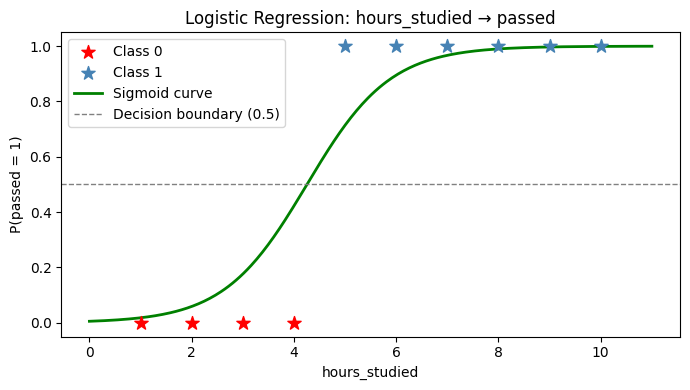

Dataset 2: Tumor Detection
Model trained on ['tumor_size'] -> 'malignant'
Epochs: 2000  |  Learning rate: 0.1
  Weight [tumor_size]: 2.3812
  Bias: -7.5329
[predict_proba] sample 1  ->  P(class=1) = 0.1708
[predict_proba] sample 2  ->  P(class=1) = 0.9602
[predict]       sample 1  ->  class = 0  (prob=0.1708)
[predict]       sample 2  ->  class = 1  (prob=0.9602)
[score] Accuracy  = 1.0000  (excellent)
        Precision = 1.0000
        Recall    = 1.0000
        F1 Score  = 1.0000


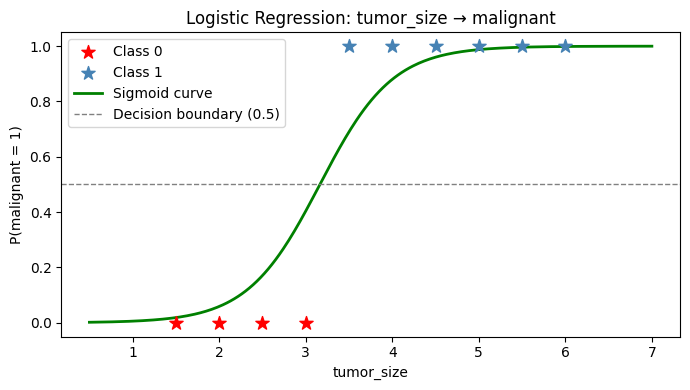

In [ ]:

#Dataset 1: Pass/Fail
print("Dataset 1: Pass/Fail")
df1 = pd.DataFrame({
    "hours_studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "passed":        [0, 0, 0, 0, 1, 1, 1, 1, 1,  1]
})
model1 = LogisticRegression(learning_rate=0.1, epochs=1000)
model1.fit(df1, x_cols="hours_studied", y_col="passed")
model1.predict([[3], [5], [8]])
model1.score()
model1.plot()

#Dataset 2: Tumor 
print("Dataset 2: Tumor Detection")
df2 = pd.DataFrame({
    "tumor_size": [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0],
    "malignant":  [0,   0,   0,   0,   1,   1,   1,   1,   1,   1  ]
})
model2 = LogisticRegression(learning_rate=0.1, epochs=2000)
model2.fit(df2, x_cols="tumor_size", y_col="malignant")
model2.predict([[2.5], [4.5]])
model2.score()
model2.plot()
